# Accedere ai dati con Pandas

Carichiamo il dataset

In [3]:
import pandas as pd
from datasets import load_dataset
from typing import cast

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df.job_posted_date)
df.sort_values("job_posted_date", inplace=True)
df.reset_index(drop=True, inplace=True)  # Reimposta l'indice numerico progressivo
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  str           
 1   job_title              785740 non-null  str           
 2   job_location           784696 non-null  str           
 3   job_via                785733 non-null  str           
 4   job_schedule_type      773074 non-null  str           
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  str           
 7   job_posted_date        785741 non-null  datetime64[us]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  str           
 11  salary_rate            33067 non-null   str           
 12  salary_year_avg        22003 non-null   float64       


Il metodo che abbiamo già visto per accedere ad una riga specifica è `iloc`, che accede alla riga in base alla sua posizione. Se invece vogliamo accedere ad una riga in base al suo indice, possiamo utilizzare il metodo `loc`.

In [9]:
df.iloc[0:10] # mostra le prime 10 righe del DataFrame, utilizzando il metodo `iloc` per accedere alle righe in base alla loro posizione.


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,NaN,NaN,NaN,Metasys Technologies,"['sql', 'snowflake', 'visio', 'jira', 'conflue...","{'analyst_tools': ['visio'], 'async': ['jira',..."
1,Data Analyst,Data Analyst,"Bloomfield, CT",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:07,True,False,United States,NaN,NaN,NaN,Diverse Lynx,"['sql', 'sas', 'sas']","{'analyst_tools': ['sas'], 'programming': ['sq..."
2,Data Analyst,Data Analyst,"Washington, DC",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:22,False,True,United States,NaN,NaN,NaN,Guidehouse,"['sql', 'python', 'r', 'azure', 'snowflake', '...","{'analyst_tools': ['tableau', 'excel'], 'cloud..."
3,Data Analyst,Data Analyst,"Fairfax, VA",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:24,False,False,United States,NaN,NaN,NaN,Protask,"['sql', 'jira']","{'async': ['jira'], 'programming': ['sql']}"
4,Senior Data Analyst,Senior Data Analyst / Platform Experience,"Worcester, MA",via LinkedIn,Full-time,False,"New York, United States",2023-01-01 00:00:27,False,True,United States,NaN,NaN,NaN,Atria Wealth Solutions,"['sql', 'atlassian', 'jira']","{'async': ['jira'], 'other': ['atlassian'], 'p..."
5,Data Analyst,Jr. Data Analyst,"Torrance, CA",via Recruit.net,Full-time,False,"California, United States",2023-01-01 00:00:38,False,False,United States,NaN,NaN,NaN,Aquent,['excel'],{'analyst_tools': ['excel']}
6,Data Analyst,Data Analyst,"Sunnyvale, CA",via CareerBuilder,Full-time,False,"California, United States",2023-01-01 00:00:38,False,False,United States,NaN,NaN,NaN,"ICONMA, LLC","['sql', 'python']","{'programming': ['sql', 'python']}"
7,Data Analyst,Data Analyst,"Pleasanton, CA",via CareerBuilder,Full-time,False,"California, United States",2023-01-01 00:00:38,True,False,United States,NaN,NaN,NaN,"RIT Solutions, Inc.","['sql', 'tableau', 'excel']","{'analyst_tools': ['tableau', 'excel'], 'progr..."
8,Data Analyst,Data Analyst,"San Francisco, CA",via Jora,Full-time,False,"California, United States",2023-01-01 00:00:43,True,False,United States,NaN,NaN,NaN,Adyen,"['r', 'python', 'sql', 'tableau', 'looker']","{'analyst_tools': ['tableau', 'looker'], 'prog..."
9,Data Engineer,Data Engineer / Data Analyst,"Orange, CA",via CareerBuilder,Full-time,False,"California, United States",2023-01-01 00:00:51,False,False,United States,NaN,NaN,NaN,Keylent,"['sql', 'nosql', 'scala', 'python', 'java', 's...","{'analyst_tools': ['ssis'], 'cloud': ['oracle'..."


In [14]:
df.loc[:, "salary_rate": "salary_hour_avg"].dropna(subset = "salary_rate") 

,salary_rate,salary_year_avg,salary_hour_avg
22,hour,NaN,20.0
64,year,110000.0,NaN
107,year,65000.0,NaN
214,year,90000.0,NaN
217,year,55000.0,NaN
...,...,...,...
785689,hour,NaN,28.0
785713,month,NaN,NaN
785719,hour,NaN,25.0
785735,year,162500.0,NaN


# Pulire i dati con Pandas

Quando ci sono `NaN` in una colonna, è possibile che ci siano anche errori di formattazione. Ad esempio, se una colonna contiene sia numeri che stringhe, potrebbe essere necessario pulire i dati prima di poterli utilizzare.

Spesso invece che eliminare le righe con `NaN`, è possibile sostituire i valori mancati con un valore di default, oppure con la media o la mediana della colonna. In questo modo, è possibile mantenere tutte le righe del dataset, anche quelle con valori mancanti.

Per farlo usiamo il metodo `fillna()`, che permette di sostituire i valori mancanti con un valore specificato. Ad esempio, se vogliamo sostituire i valori mancanti nella colonna `salary_year_avg` con la mediana della colonna, possiamo fare così:

In [11]:
median_year_salary = df["salary_year_avg"].median()
print(median_year_salary)

median_hour_salary = df["salary_hour_avg"].median()
print(median_hour_salary)

115000.0
45.97999954223633


In [14]:
df_filled = df.copy()  # Usiamo `copy()` per non modificare il DataFrame originale
df_filled["salary_year_avg"] = df_filled["salary_year_avg"].fillna(median_year_salary)
df_filled["salary_hour_avg"] = df_filled["salary_hour_avg"].fillna(median_hour_salary)

median_year_salary_filled = df_filled["salary_year_avg"].median()
print(median_year_salary_filled)

median_hour_salary_filled = df_filled["salary_hour_avg"].median()
print(median_hour_salary_filled)

115000.0
45.97999954223633


In [16]:
df_filled.loc[1:10, "salary_rate":"salary_hour_avg"]

,salary_rate,salary_year_avg,salary_hour_avg
1,NaN,115000.0,45.98
2,NaN,115000.0,45.98
3,NaN,115000.0,45.98
4,NaN,115000.0,45.98
5,NaN,115000.0,45.98
6,NaN,115000.0,45.98
7,NaN,115000.0,45.98
8,NaN,115000.0,45.98
9,NaN,115000.0,45.98
10,NaN,115000.0,45.98


Un'altra cosa che possiamo fare è eliminare i duplicati, se ci sono. Per farlo, possiamo utilizzare il metodo `drop_duplicates()`, che elimina le righe duplicate in base a una o più colonne specificate.

In [18]:
df_unique = df_filled.drop_duplicates() # Elimina le righe duplicate dal DataFrame `df_filled` e crea un nuovo DataFrame `df_unique` che contiene solo le righe uniche.

print(f"Lunghezza del DataFrame originale: {len(df)}")
print(f"Lunghezza del DataFrame con duplicati eliminati: {len(df_unique)}")
print(f"Numero di righe duplicate eliminate: {len(df) - len(df_unique)}")


Lunghezza del DataFrame originale: 785741
Lunghezza del DataFrame con duplicati eliminati: 785640
Numero di righe duplicate eliminate: 101


Per eliminare i duplicati in maniera più specifica, possiamo passare una lista di colonne al metodo `drop_duplicates()`, in modo da eliminare solo le righe che sono duplicate in quelle colonne.

In [19]:
df_unique = df_unique.drop_duplicates(subset = ["job_title", "company_name"])

print(f"Lunghezza del DataFrame originale: {len(df)}")
print(f"Lunghezza del DataFrame con duplicati eliminati: {len(df_unique)}")
print(f"Numero di righe duplicate eliminate: {len(df) - len(df_unique)}")

Lunghezza del DataFrame originale: 785741
Lunghezza del DataFrame con duplicati eliminati: 508042
Numero di righe duplicate eliminate: 277699


# Pandas: Data Management

In questa sezione vedremo `df.sample()`, un metodo molto utile per prendere un campione casuale di righe da un DataFrame. Questo è particolarmente utile quando si lavora con dataset molto grandi, in quanto permette di analizzare una parte del dataset senza dover caricare tutto in memoria.

E `df.copy()`, un metodo che permette di creare una copia del DataFrame, in modo da poter lavorare su una copia dei dati senza modificare l'originale. Questo è particolarmente utile quando si vogliono fare modifiche ai dati senza rischiare di perdere l'originale.

In [24]:
df.sample(5, random_state=42) # Prende un campione casuale di 5 righe dal DataFrame `df`, utilizzando un seme casuale di 42 per garantire la riproducibilità del campione.

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
502901,Senior Data Analyst,HR Decision Scientist,"Burbank, CA",via LinkedIn,Full-time,False,"California, United States",2023-08-19 12:03:05,False,True,United States,NaN,NaN,NaN,The Walt Disney Company,"['python', 'sql', 'snowflake', 'redshift', 'ta...","{'analyst_tools': ['tableau', 'cognos'], 'clou..."
406337,Business Analyst,"Business Intelligence Analyst, ANSA Polymer Ltd.","Port of Spain, Trinidad and Tobago",via Caribbean Jobs,Full-time,False,Trinidad and Tobago,2023-07-05 20:17:08,False,False,Trinidad and Tobago,NaN,NaN,NaN,ANSA McAL Group of Companies,"['c', 'sql', 'python', 'r', 'express', 'dax']","{'analyst_tools': ['dax'], 'programming': ['c'..."
659951,Data Engineer,Data Engineer Internship,"Phoenix, AZ",via Trabajo.org,Full-time and Internship,False,"New York, United States",2023-10-29 03:04:05,False,False,United States,NaN,NaN,NaN,Amazon,['flow'],{'other': ['flow']}
541593,Senior Data Scientist,Senior Data Scientist,"Scottsdale, AZ",via LinkedIn,Full-time,False,"California, United States",2023-09-02 18:04:06,False,False,United States,NaN,NaN,NaN,Cardone Ventures,"['sql', 'c#', 'java', 'python', 'azure', 'aws'...","{'analyst_tools': ['power bi', 'tableau'], 'cl..."
425158,Senior Data Analyst,Senior Data Analyst,"Atlanta, GA",via LinkedIn,Contractor,False,Georgia,2023-07-14 13:53:46,True,True,United States,NaN,NaN,NaN,Kforce Inc,"['sql', 'tableau']","{'analyst_tools': ['tableau'], 'programming': ..."


Quando si vuole creare una copia di un DataFrame, si potrebbe essere tentati di utilizzare l'operatore di assegnazione `=`, ma questo non crea una copia del DataFrame, ma solo un riferimento ad esso. In questo modo, se si modifica la copia, si modifica anche l'originale. Per creare una copia del DataFrame, è necessario utilizzare il metodo `copy()`.

Il metodo `copy` ha un parametro `deep` che, se impostato a `True`, crea una copia profonda del DataFrame, ovvero una copia indipendente che non condivide alcun dato con l'originale. Se invece `deep` è impostato a `False`, viene creata una copia superficiale, che condivide i dati con l'originale. Di default, `deep` è impostato a `True`.

# Pandas: Pivot Table
Una pivot table è una tabella che permette di riassumere i dati in modo da poterli analizzare più facilmente. In Pandas, è possibile creare una pivot table utilizzando il metodo `pivot_table()`, che permette di specificare le colonne da utilizzare come indice, le colonne da utilizzare come valori e le funzioni di aggregazione da utilizzare per riassumere i dati.

job_title_short  Data Analyst  Data Engineer  Data Scientist
job_country                                                 
United States         90000.0       125000.0        130000.0
India                100500.0       147500.0        114008.0
United Kingdom        87750.0       110000.0        105300.0
France                69175.0        98301.5         88128.0
Germany              103750.0       147500.0        131560.0
Spain                 91977.0       133000.0         88128.0


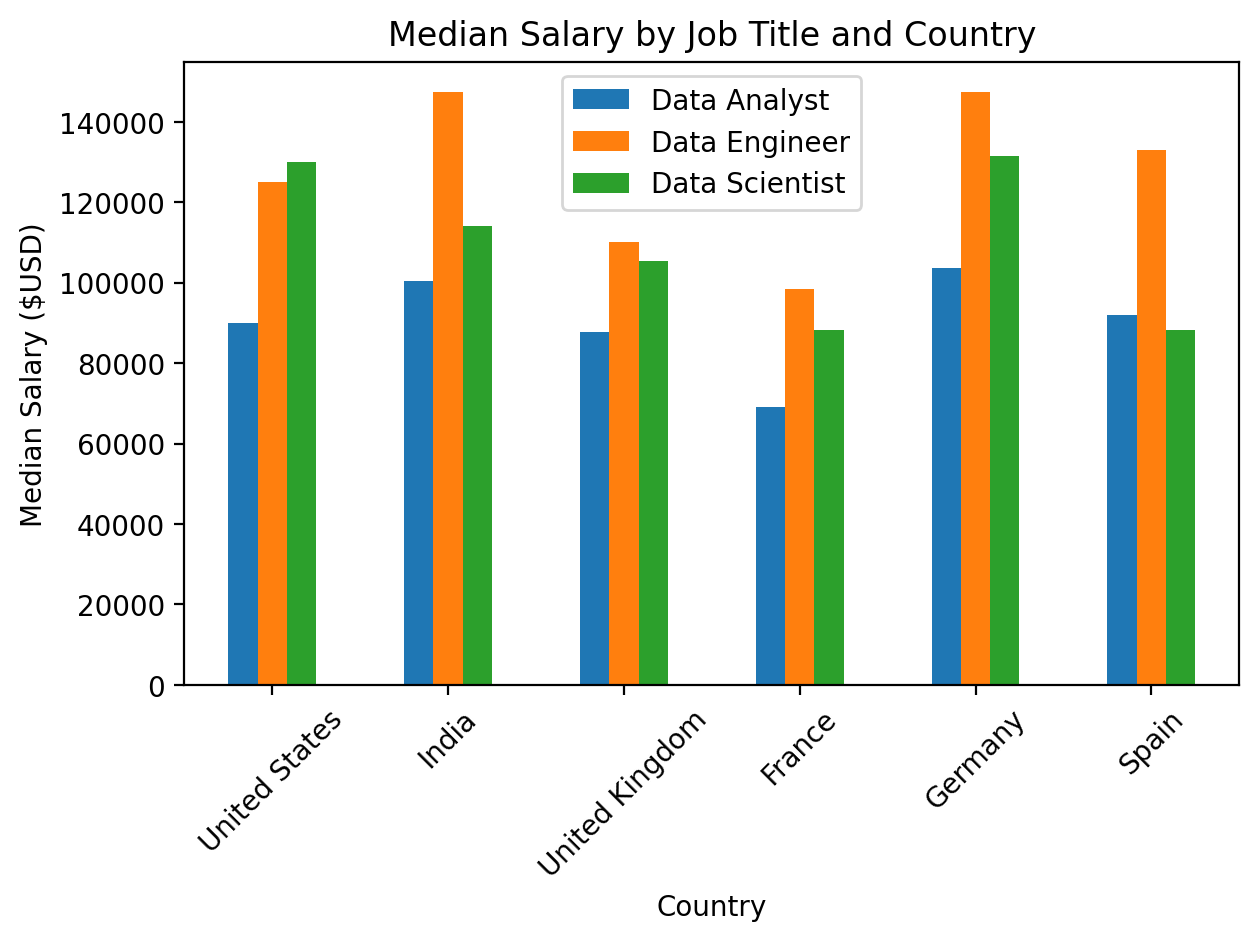

In [41]:
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
df_job_countries_salary = df.pivot_table(index="job_country",values="salary_year_avg", columns = "job_title_short", aggfunc="median")

top_countries = df["job_country"].value_counts().head(6).index
job_titles = ["Data Analyst", "Data Engineer", "Data Scientist"]

df_job_countries_salary_top = df_job_countries_salary[job_titles].loc[top_countries]

print(df_job_countries_salary_top)

df_job_countries_salary_top.plot(kind="bar", title="Median Salary by Job Title and Country")
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Median Salary ($USD)")
plt.legend()
plt.tight_layout()  # Per evitare sovrapposizioni

# Pandas: Index Management
In questa sezione vedremo come gestire gli indici in un DataFrame. Gli indici sono importanti perché permettono di accedere ai dati in modo più efficiente e di eseguire operazioni di join e merge in modo più semplice. Vedremo come impostare un indice, come resettare un indice e come utilizzare gli indici per accedere ai dati in modo più efficiente.

In particolare vedremo come utilizzare il metodo `sort_index()`, che permette di ordinare un DataFrame in base all'indice, e il metodo `set_index()`, che permette di impostare una colonna come indice del DataFrame.

In [18]:
import pandas as pd
from datasets import load_dataset
from typing import cast
import matplotlib.pyplot as plt

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

Vediamo prima di tutto `index.name` e `index.dtype`, che permettono di visualizzare il nome e il tipo dell'indice del DataFrame. Questi sono utili per capire come è strutturato il DataFrame e per verificare che l'indice sia stato impostato correttamente.

In [19]:
print(df.index)
print(df.index.name)
print(df.index.dtype)

RangeIndex(start=0, stop=785741, step=1)
None
int64


Assegnamo ora un nome all'indice del DataFrame, in modo da poterlo identificare più facilmente. Per farlo, possiamo utilizzare il metodo `index.name`, che permette di assegnare un nome all'indice del DataFrame.

In [20]:
df.index.name = "job_id"
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
job_id,,,,,,,,,,,,,,,,,
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."


Ora vediamo i tre seguenti metodi per gestire gli indici in un DataFrame: `sort_index()`, `set_index()` e `reset_index()`. Questi metodi permettono di ordinare un DataFrame in base all'indice, di impostare una colonna come indice del DataFrame e di resettare l'indice del DataFrame, rispettivamente.

In [21]:
df_usa = df[df["job_country"] == "United States"]
df_usa.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
job_id,,,,,,,,,,,,,,,,,
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '..."
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."


In [22]:
df_usa.reset_index(inplace=True) 
df_usa.head()

,job_id,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
2,5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '..."
3,6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
4,9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."


In [23]:
df_usa.set_index("job_id", inplace=True)
df_usa.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
job_id,,,,,,,,,,,,,,,,,
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '..."
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."


In [28]:
median_pivot = df_usa.pivot_table(index ='job_title_short', values = "salary_year_avg", aggfunc = ['min', 'max', 'median'])
median_pivot

,min,max,median
,salary_year_avg,salary_year_avg,salary_year_avg
job_title_short,,,
Business Analyst,35000.0,387460.0,90000.0
Cloud Engineer,42000.0,221844.0,116100.0
Data Analyst,25000.0,375000.0,90000.0
Data Engineer,23496.0,525000.0,125000.0
Data Scientist,30000.0,960000.0,130000.0
Machine Learning Engineer,44408.5,315000.0,150000.0
Senior Data Analyst,35360.0,425000.0,110000.0
Senior Data Engineer,45000.0,375000.0,150000.0


In [30]:
median_pivot.sort_values(by=('median', 'salary_year_avg'), ascending=False)

,min,max,median
,salary_year_avg,salary_year_avg,salary_year_avg
job_title_short,,,
Senior Data Scientist,55000.0,475000.0,155000.0
Machine Learning Engineer,44408.5,315000.0,150000.0
Senior Data Engineer,45000.0,375000.0,150000.0
Data Scientist,30000.0,960000.0,130000.0
Software Engineer,48982.0,375000.0,130000.0
Data Engineer,23496.0,525000.0,125000.0
Cloud Engineer,42000.0,221844.0,116100.0
Senior Data Analyst,35360.0,425000.0,110000.0


In [31]:
median_pivot.sort_index() # Ordina il DataFrame `median_pivot` in base all'indice (`job_title_short`) in ordine crescente.

,min,max,median
,salary_year_avg,salary_year_avg,salary_year_avg
job_title_short,,,
Business Analyst,35000.0,387460.0,90000.0
Cloud Engineer,42000.0,221844.0,116100.0
Data Analyst,25000.0,375000.0,90000.0
Data Engineer,23496.0,525000.0,125000.0
Data Scientist,30000.0,960000.0,130000.0
Machine Learning Engineer,44408.5,315000.0,150000.0
Senior Data Analyst,35360.0,425000.0,110000.0
Senior Data Engineer,45000.0,375000.0,150000.0


## Esercizio: Domanda mensile di lavoro


In [73]:
import pandas as pd
from datasets import load_dataset
from typing import cast
import matplotlib.pyplot as plt

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

In [74]:
df_US = df[df["job_country"] == "United States"].copy()
df_US.head()


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '..."
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."


Estraiamo i nomi dei mesi

In [75]:
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')
df_US.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN,June
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",July
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '...",November
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",March
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",April


Adesso creiamo una tabella pivot che mostra il numero di offerte di lavoro per ogni mese, in modo da poter analizzare la domanda mensile di lavoro negli Stati Uniti. Per farlo, possiamo utilizzare il metodo `pivot_table()`, specificando la colonna `job_posted_month` come indice, la colonna `job_id` come valori e la funzione di aggregazione `count` per contare il numero di offerte di lavoro per ogni mese.

In [76]:
df_US_pivot = df_US.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')
df_US_pivot.reset_index(inplace=True)
df_US_pivot['month_number'] = pd.to_datetime(df_US_pivot['job_posted_month'], format='%B').dt.month
df_US_pivot.sort_values('month_number', inplace=True)
df_US_pivot.set_index('job_posted_month', inplace=True)
df_US_pivot.drop(columns='month_number', inplace=True)
df_US_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


Adesso possiamo mostrare graficamente la domanda mensile di lavoro negli Stati Uniti utilizzando un grafico a barre. Per farlo, possiamo utilizzare il metodo `plot.bar()`, specificando la colonna `job_posted_month` come asse x e la colonna `job_id` come asse y. In questo modo, possiamo visualizzare la domanda mensile di lavoro negli Stati Uniti in modo più chiaro e intuitivo.

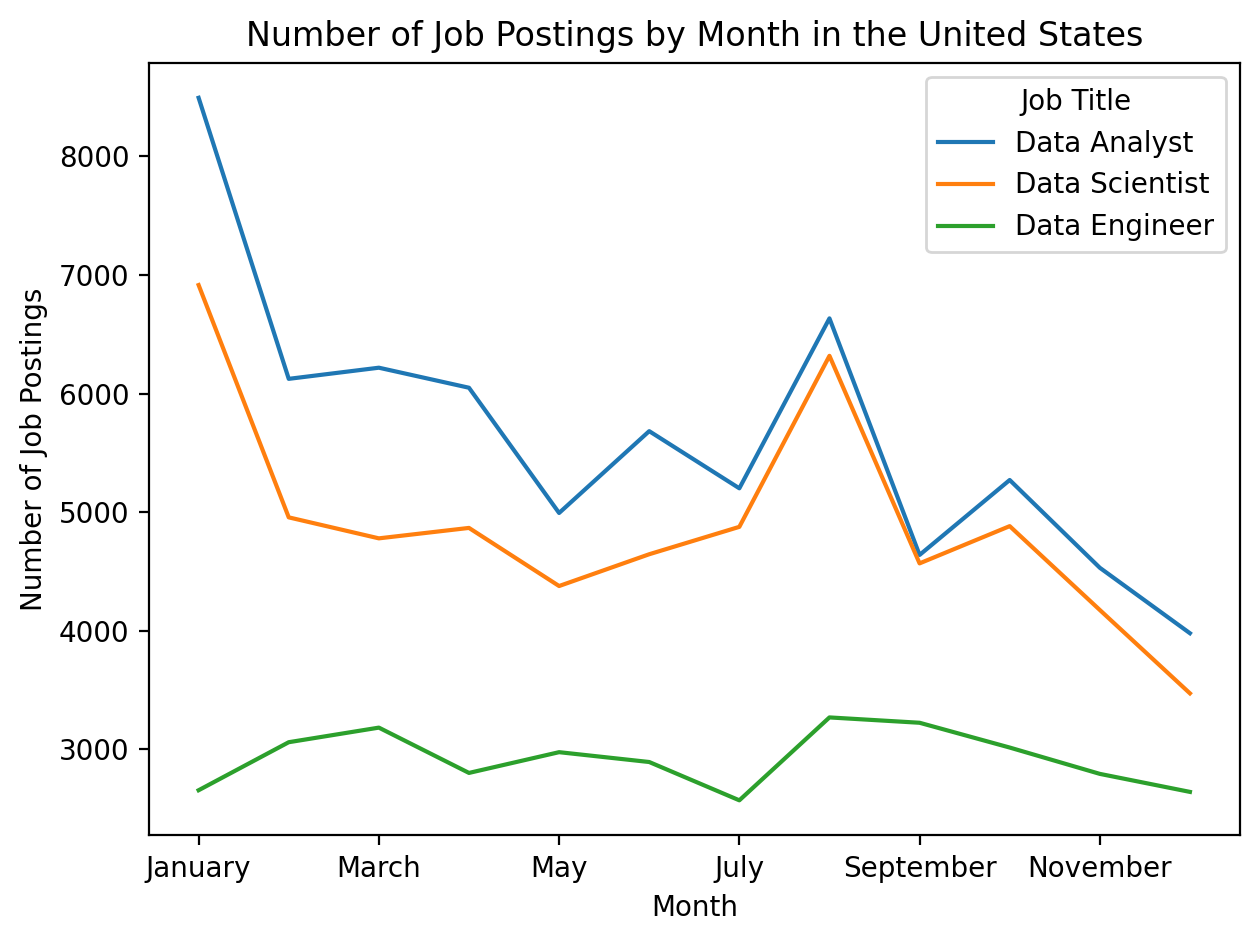

In [94]:
%config InlineBackend.figure_format = 'retina'
top_3 = df_US['job_title_short'].value_counts().head(3).index
df_US_pivot[top_3].plot(kind="line", title="Number of Job Postings by Month in the United States")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.legend(title="Job Title")
plt.tight_layout()  # Per evitare sovrapposizioni

# Pandas: Merge DataFrames
In questa sezione vedremo come unire due DataFrame utilizzando il metodo `merge()`, che permette di unire due DataFrame in base a una o più colonne chiave. Vedremo anche come utilizzare il metodo `concat()`, che permette di concatenare due o più DataFrame lungo un asse specificato. Questi metodi sono molto utili quando si lavora con dataset che sono stati divisi in più parti o quando si vogliono unire dati provenienti da fonti diverse.

In [84]:
# Aggiungiamo un nuovo database
df_US_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col=0)
df_US_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


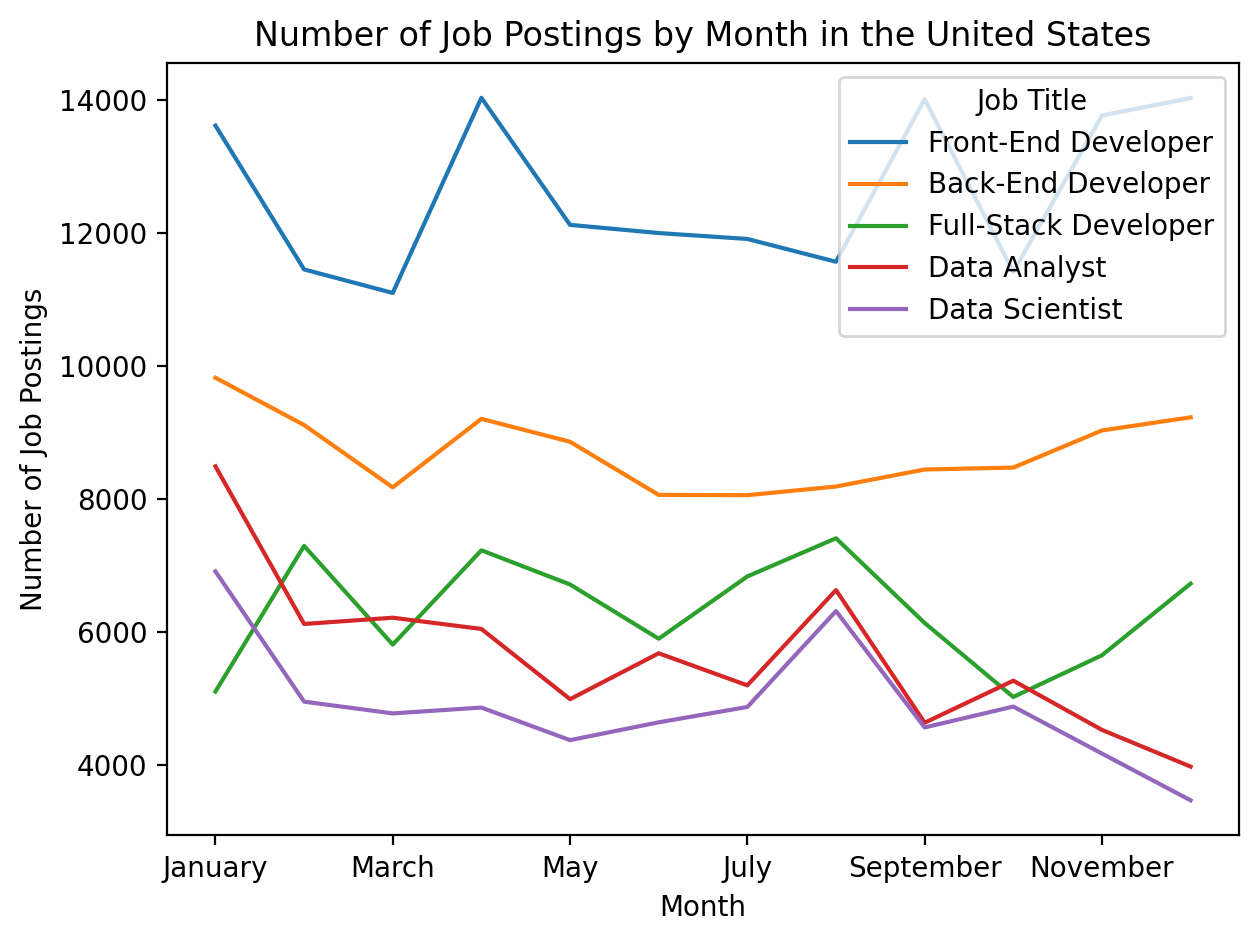

In [95]:
%config InlineBackend.figure_format = 'retina'
# Adesso uniamo i due Dataframe
df_US_merged = df_US_pivot.merge(df_US_software_pivot, on="job_posted_month")
top_5 = df_US_merged.sum().sort_values(ascending=False).head(5).index
df_US_merged[top_5].plot(kind="line", title="Number of Job Postings by Month in the United States")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.legend(title="Job Title")
plt.tight_layout()  # Per evitare sovrapposizioni 

Adesso vediamo il `concat()`, un metodo che permette di concatenare due o più DataFrame lungo un asse specificato. Questo è particolarmente utile quando si vogliono unire dati provenienti da fonti diverse o quando si vogliono unire dati che sono stati divisi in più parti. Per utilizzare `concat()`, è necessario specificare i DataFrame da concatenare e l'asse lungo cui concatenarli. Ad esempio, se si vogliono concatenare due DataFrame lungo l'asse delle righe, è necessario specificare `axis=0`, mentre se si vogliono concatenare lungo l'asse delle colonne, è necessario specificare `axis=1`.



In [110]:
import pandas as pd
from datasets import load_dataset
from typing import cast

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df.job_posted_date)
df.sort_values("job_posted_date", inplace=True)

In [114]:
# Creiamo un dizionario che contiene i DataFrame per ogni mese
df["job_posted_month"] = df["job_posted_date"].dt.strftime('%b')

months = df["job_posted_month"].unique()

dict_months = {month: df[df["job_posted_month"] == month] for month in months}

dict_months["Jan"].head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
108804,Data Analyst,Data Analyst,"New York, NY",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:04,False,False,United States,NaN,NaN,NaN,Metasys Technologies,"['sql', 'snowflake', 'visio', 'jira', 'conflue...","{'analyst_tools': ['visio'], 'async': ['jira',...",Jan
96906,Data Analyst,Data Analyst,"Bloomfield, CT",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:07,True,False,United States,NaN,NaN,NaN,Diverse Lynx,"['sql', 'sas', 'sas']","{'analyst_tools': ['sas'], 'programming': ['sq...",Jan
98438,Data Analyst,Data Analyst,"Washington, DC",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:22,False,True,United States,NaN,NaN,NaN,Guidehouse,"['sql', 'python', 'r', 'azure', 'snowflake', '...","{'analyst_tools': ['tableau', 'excel'], 'cloud...",Jan
110290,Data Analyst,Data Analyst,"Fairfax, VA",via CareerBuilder,Full-time,False,"New York, United States",2023-01-01 00:00:24,False,False,United States,NaN,NaN,NaN,Protask,"['sql', 'jira']","{'async': ['jira'], 'programming': ['sql']}",Jan
72158,Senior Data Analyst,Senior Data Analyst / Platform Experience,"Worcester, MA",via LinkedIn,Full-time,False,"New York, United States",2023-01-01 00:00:27,False,True,United States,NaN,NaN,NaN,Atria Wealth Solutions,"['sql', 'atlassian', 'jira']","{'async': ['jira'], 'other': ['atlassian'], 'p...",Jan


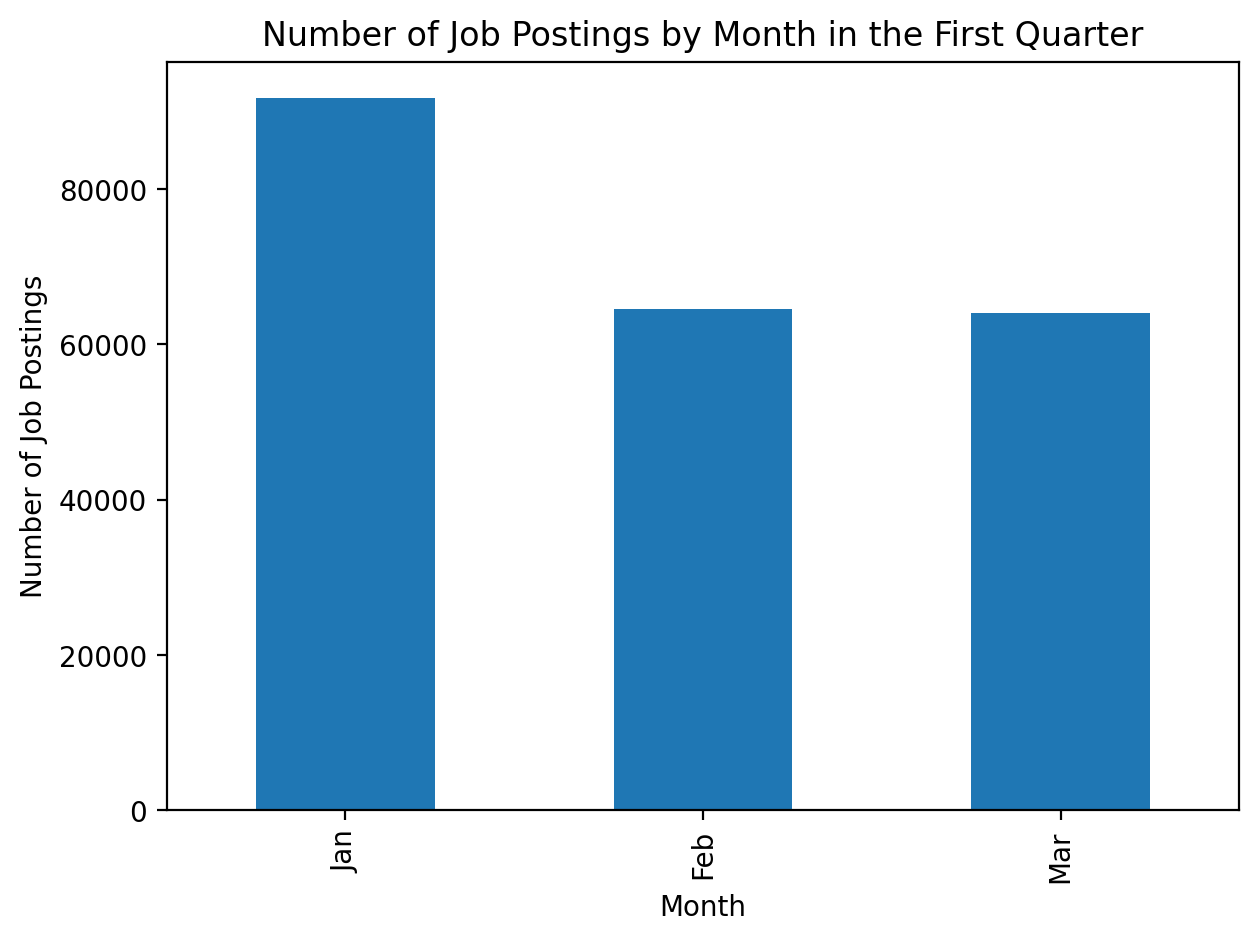

In [130]:
# Il capo richiede i dati del primo trimestre
df_first_quarter = pd.concat([dict_months["Jan"], dict_months["Feb"], dict_months["Mar"]])
df_first_quarter["job_posted_month"].value_counts().plot(kind="bar", title="Number of Job Postings by Month in the First Quarter")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.tight_layout()  # Per evitare sovrapposizioni

# Pandas: `df.apply(lambda x: ... )`

La funzione `apply()` è un metodo molto potente che permette di applicare una funzione a ogni elemento di una colonna o di un DataFrame. In particolare, è possibile utilizzare `apply()` insieme a una funzione lambda per eseguire operazioni personalizzate sui dati. Ad esempio, se si vuole creare una nuova colonna che contiene il numero di parole in una colonna di testo, è possibile utilizzare `apply()` con una funzione lambda che conta le parole in ogni elemento della colonna.

In [153]:
import pandas as pd
from datasets import load_dataset
from typing import cast
import matplotlib.pyplot as plt

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

In [154]:
# Puliamo i dati
df_cleaned = df[pd.notna(df["salary_year_avg"])].copy()
cleaned_salary = df_cleaned["salary_year_avg"]
cleaned_salary.head()

28     109500.0
77     140000.0
92     120000.0
100    228222.0
109     89000.0
Name: salary_year_avg, dtype: float64

Per calcolare il salario proiettato per il prossimo anno, possiamo utilizzare `apply()` con una funzione lambda che moltiplica il salario attuale per un fattore di crescita. Ad esempio, se si vuole proiettare il salario per il prossimo anno con un tasso di crescita del 3%, è possibile utilizzare `apply()` con una funzione lambda che moltiplica il salario attuale per 1.03.

In [155]:
def project_salary(salary):
        return salary * 1.03
    
df_cleaned["projected_salary_year_avg"] = df_cleaned["salary_year_avg"].apply(project_salary)
df_cleaned[["salary_year_avg", "projected_salary_year_avg"]].head()

,salary_year_avg,projected_salary_year_avg
28,109500.0,112785.00
77,140000.0,144200.00
92,120000.0,123600.00
100,228222.0,235068.66
109,89000.0,91670.00


In [156]:
# Usando una funzione lambda
df_cleaned["projected_salary_year_avg_lambda"] = df_cleaned["salary_year_avg"].apply(lambda salary: salary * 1.03)
df_cleaned[["salary_year_avg", "projected_salary_year_avg_lambda"]].head()

,salary_year_avg,projected_salary_year_avg_lambda
28,109500.0,112785.00
77,140000.0,144200.00
92,120000.0,123600.00
100,228222.0,235068.66
109,89000.0,91670.00


Vediamo ora come utilizzare `apply()` in un contesto diverso. La colonna `job_skills` contiene una stringa con una lista di competenze richieste per ogni offerta di lavoro. Usando il modulo `ast`, possiamo utilizzare `apply()` con una funzione lambda per convertire la stringa in una lista di competenze. In questo modo, possiamo analizzare le competenze richieste per ogni offerta di lavoro in modo più efficace.

In [169]:
import ast

df["job_skills_list"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

df[["job_skills", "job_skills_list"]].head()

,job_skills,job_skills_list
0,NaN,[]
1,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","[r, python, sql, nosql, power bi, tableau]"
2,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","[python, sql, c#, azure, airflow, dax, docker,..."
3,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","[python, c++, java, matlab, aws, tensorflow, k..."
4,"['bash', 'python', 'oracle', 'aws', 'ansible',...","[bash, python, oracle, aws, ansible, puppet, j..."


**Esercizio**: Calcola il salario proiettato per il prossimo anno. I ruoli senior hanno un tasso di crescita del 5%, mentre gli altri ruoli hanno un tasso di crescita del 3%. Utilizza `apply()` con una funzione lambda per calcolare il salario proiettato per ogni offerta di lavoro, tenendo conto del tasso di crescita specifico per i ruoli senior e non senior.

In [178]:
def project_salary(row):
    if "senior" in row["job_title_short"].lower():
        return row["salary_year_avg"] * 1.05
    else:
        return row["salary_year_avg"] * 1.03

df_cleaned['salary_year_inflated'] = df_cleaned.apply(project_salary, axis=1)

df_cleaned[["job_title_short", "salary_year_avg", "salary_year_inflated"]].head(20)

# Utilizzando la funzione lambda

df_cleaned['salary_year_inflated_lambda'] = df_cleaned.apply(lambda row: row['salary_year_avg'] * 1.05 if 'senior' in row['job_title_short'] else row['salary_year_avg'] * 1.03, axis=1)

df_cleaned[["job_title_short", "salary_year_avg", "salary_year_inflated","salary_year_inflated_lambda"]].head(20)

,job_title_short,salary_year_avg,salary_year_inflated,salary_year_inflated_lambda
28,Data Scientist,109500.0,112785.00,112785.00
77,Data Engineer,140000.0,144200.00,144200.00
92,Data Engineer,120000.0,123600.00,123600.00
100,Data Scientist,228222.0,235068.66,235068.66
109,Data Analyst,89000.0,91670.00,91670.00
116,Data Scientist,114000.0,117420.00,117420.00
146,Data Engineer,129500.0,133385.00,133385.00
180,Data Analyst,90250.0,92957.50,92957.50
212,Data Scientist,157500.0,162225.00,162225.00
257,Data Scientist,103128.0,106221.84,106221.84


# Pandas: `df.explode()`
Il metodo `explode()` è un metodo molto utile che permette di "esplodere" una colonna che contiene liste in più righe, in modo da poter analizzare i dati in modo più efficace. Ad esempio, se si ha una colonna che contiene una lista di competenze richieste per ogni offerta di lavoro, è possibile utilizzare `explode()` per creare una nuova riga per ogni competenza, in modo da poter analizzare le competenze richieste per ogni offerta di lavoro in modo più dettagliato.

In [186]:
import pandas as pd
from datasets import load_dataset
from typing import cast
import matplotlib.pyplot as plt

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df['job_skills'] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [187]:
df_exploded = df.explode("job_skills")
df_exploded.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."


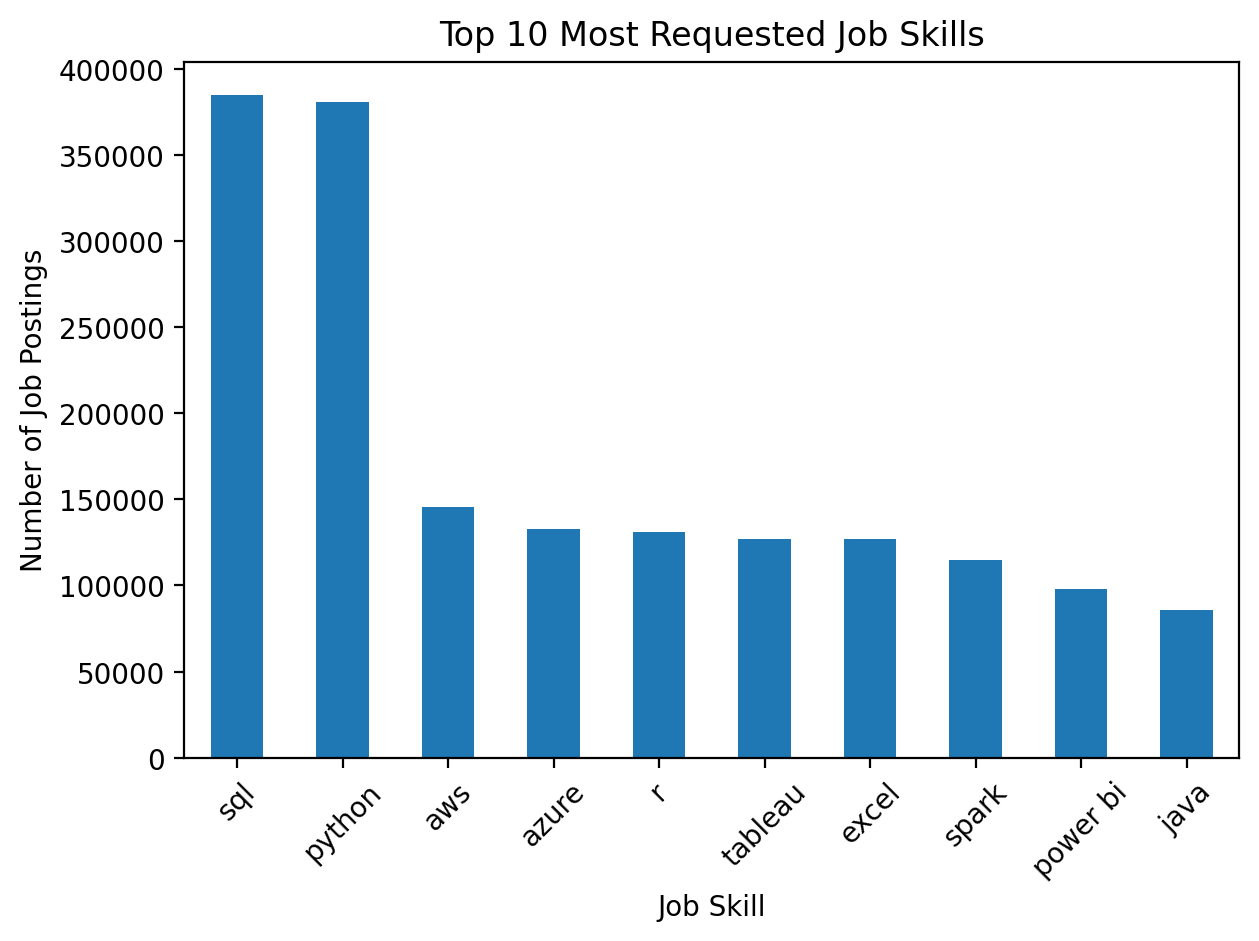

In [188]:
# Rappresentiamo graficamente le competenze più richieste
top_skills = df_exploded["job_skills"].value_counts().head(10)
top_skills.plot(kind="bar", title="Top 10 Most Requested Job Skills")
plt.xlabel("Job Skill")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.tight_layout()  # Per evitare sovrapposizioni

Rendiamo ora il codice più interattivo, chiediamo all'utente di inserire il numero di competenze più richieste da visualizzare ed il tipo di lavoro (Data Analyst, Data Scientist, Software Engineer, ecc.) per visualizzare le competenze più richieste per quel tipo di lavoro. Utilizziamo `explode()` per analizzare le competenze richieste per ogni offerta di lavoro in modo più dettagliato e `value_counts()` per contare il numero di volte che ogni competenza viene richiesta. Infine, utilizziamo un grafico a barre per visualizzare le competenze più richieste in modo chiaro e intuitivo.

In [203]:
skills_count = df_exploded.groupby(['job_title_short', 'job_skills']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_title_short,job_skills,skill_count
1066,Data Scientist,python,113711
865,Data Engineer,sql,113130
830,Data Engineer,python,108022
625,Data Analyst,sql,92428
1101,Data Scientist,sql,78982
...,...,...,...
266,Cloud Engineer,delphi,1
1920,Senior Data Scientist,objective-c,1
1400,Senior Data Analyst,couchdb,1
298,Cloud Engineer,haskell,1


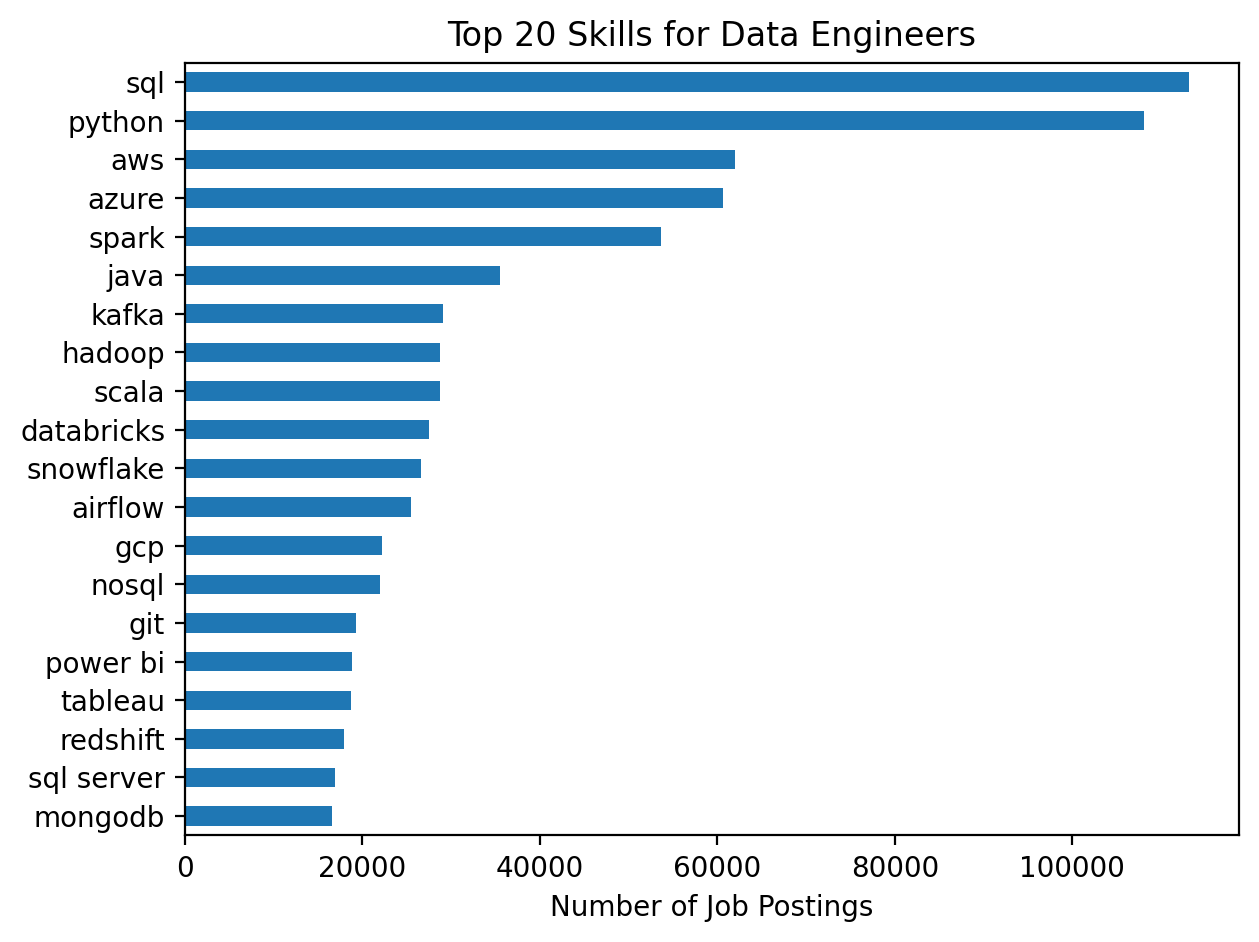

In [210]:
job_titles = df["job_title_short"].unique()
# Chiediamo all'utente di inserire un titolo di lavoro e il numero di competenze da visualizzare, se il titolo di lavoro è presente nel dataset visualizziamo le competenze più richieste per quel titolo di lavoro, altrimenti mostriamo un messaggio di errore.
job_title = input(f"Enter a job title from the following options: {', '.join(job_titles)}: ")
if job_title not in job_titles:
    print("Invalid job title. Please choose from the provided options.")
    # richiediamo all'utente di inserire un titolo di lavoro valido finché non lo fa
    while job_title not in job_titles:
        job_title = input(f"Enter a valid job title from the following options: {', '.join(job_titles)}: ")

num_skills = int(input("Enter the number of top skills to display: "))

df_skills_final = df_skills_count[df_skills_count["job_title_short"] == job_title].head(num_skills)
df_skills_final.sort_values(by="skill_count", ascending=True, inplace=True)
df_skills_final.plot(kind="barh", x="job_skills", y="skill_count", title=f"Top {num_skills} Skills for {job_title}s")
plt.xlabel("Number of Job Postings")
plt.ylabel("")
plt.legend().set_visible(False)
plt.tight_layout()  # Per evitare sovrapposizioni


**Esercizio: Trend delle skills**

In [212]:
import ast
import pandas as pd
from datasets import load_dataset
from typing import cast

dataset = load_dataset("lukebarousse/data_jobs")
df = cast(pd.DataFrame, dataset["train"].to_pandas())

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df['job_skills'] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])


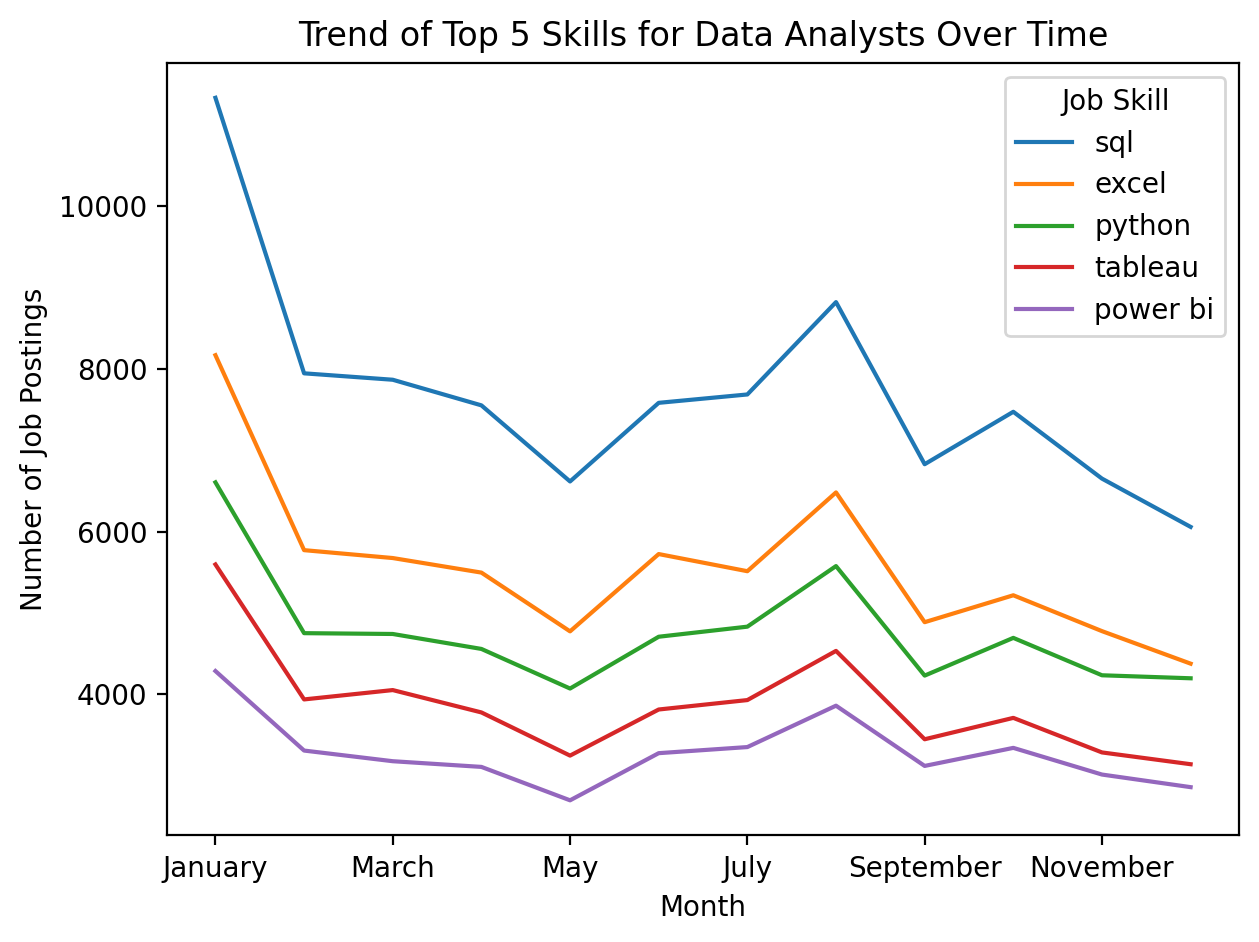

In [239]:
# Creiamo un nuovo DataFrame che contiene solo le offerte di lavoro per Data Analyst e la colonna del mese in cui sono state pubblicate
months_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Filtriamo il DataFrame per le offerte di lavoro per Data Analyst e creiamo una colonna per il mese in cui sono state pubblicate
df_DA = df[df["job_title_short"] == "Data Analyst"].copy()

# Creiamo una colonna per il mese in cui sono state pubblicate le offerte di lavoro
df_DA["job_posted_month"] = df_DA["job_posted_date"].dt.strftime("%B")

# Esplodiamo la colonna delle competenze per avere una riga per ogni competenza richiesta in ogni offerta di lavoro
df_DA_explode = df_DA.explode("job_skills")

# Identifichiamo le 5 competenze più richieste per i Data Analyst e creiamo un grafico a linee che mostra il trend di queste competenze nel tempo.
top_5_skills = df_DA_explode["job_skills"].value_counts().head(5).index

# Creiamo un DataFrame pivot che mostra il numero di offerte di lavoro per ogni competenza richiesta per i Data Analyst in ogni mese, e poi creiamo un grafico a linee per visualizzare il trend di queste competenze nel tempo.
df_DA_pivot = (
    df_DA_explode[df_DA_explode["job_skills"].isin(top_5_skills)]
    .groupby(["job_posted_month", "job_skills"])
    .size()
    .unstack(fill_value=0)
    .reindex(months_order)
)

# Ordina la legenda in base al picco massimo di ciascuna skill
column_order = df_DA_pivot.max().sort_values(ascending=False).index
df_DA_pivot = df_DA_pivot[column_order]

df_DA_pivot.plot(kind="line", title="Trend of Top 5 Skills for Data Analysts Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.legend(title="Job Skill")
plt.tight_layout()


In [ ]:
median_year_salary = df["salary_year_avg"].median()
print(median_year_salary)

median_hour_salary = df["salary_hour_avg"].median()
print(median_hour_salary)

115000.0
45.97999954223633
